# Tarea Examen 1

Nombre: **Iván Márquez Velázquez**

### Física Computacional 2026-2

Resuelva los siguientes ejercicios.

1. Genere una función que se llame ```mi_plot(x,y,gap=1,label=" ")``` que haga la gráfica de una función no contínua y que no dibuje una línea vertical. Para ello utilice el parámetro ```gap``` para indicar cual sería la mínima discontinuidad que se debe tomar en cuenta para que el graficador no realice la línea vertical. Verifique el funcionamiento de su función con 3 ejemplos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

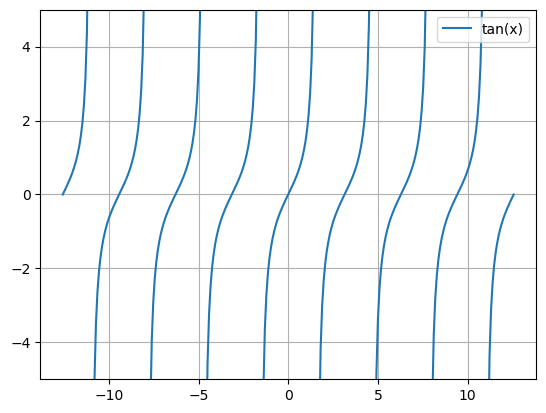

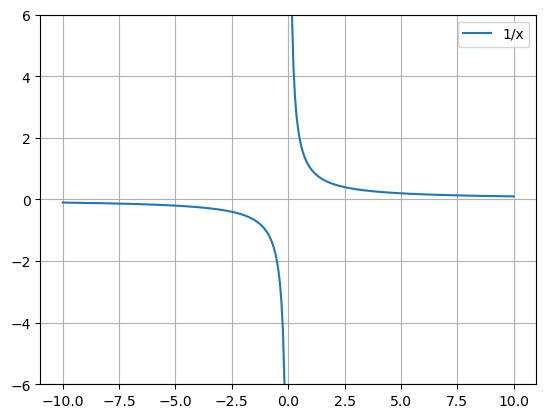

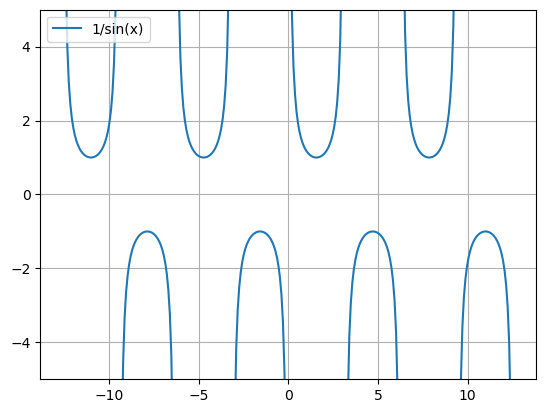

In [3]:
def mi_plot(x,y,gap=1,label=" "):
    for i in range(2,len(x)):
        dif = y[i]-2*y[i-1]+y[i-2]    #calculé la diferencia entre cada dos puntos, para poder determinar algún posible salto
        if abs(dif)>gap:
            y[i-1]=np.nan
    plt.plot(x,y,label = label)
    plt.legend()

# Dominios

x_tan = np.linspace(-4*np.pi,4*np.pi,300)
x_cociente = np.linspace(-10,10,300)
x_cosecante = np.linspace(-4*np.pi,4*np.pi,300)

#Funciones prueba

tan = np.tan(x_tan)
cociente = 1/x_cociente
cosecante = 1/np.sin(x_cosecante)

#graficas usando la función mi_plot

plt.figure(1)
mi_plot(x_tan,tan,gap=67,label="tan(x)")
plt.ylim(-5,5)
plt.grid()

plt.figure(2)
mi_plot(x_cociente,cociente,gap=79,label="1/x")
plt.ylim(-6,6)
plt.grid()

plt.figure(3)
mi_plot(x_cosecante,cosecante,gap=63,label="1/sin(x)")
plt.ylim(-5,5)
plt.grid()

#salieron gaps así porque puse muchos puntos en los dominios jeje

2. Se tiene la siguiente función definida en el intervalo $[0,1]$:
$$
f(x)= \left\{ \begin{matrix}
{\rm Ai}(10x + ai_0 ) \textrm{ si } |x| \leq 1 \\ 
0 \textrm{ si } |x| > 1 \end{matrix} 
\right.
$$
donde $Ai(x)$ es la función de Airy, y $ai_0$ es la raíz de dicha función más cercana al cero. Defina una funcion $g(x)$ como la repetición periódica de dicha función para $x\in \mathbb{R}$. Verifique el resultado haciendo la gráfica de dicha función en el intervalo $[-10,10]$ o cualquier otro intervalo cuyo dominio sea mayor.

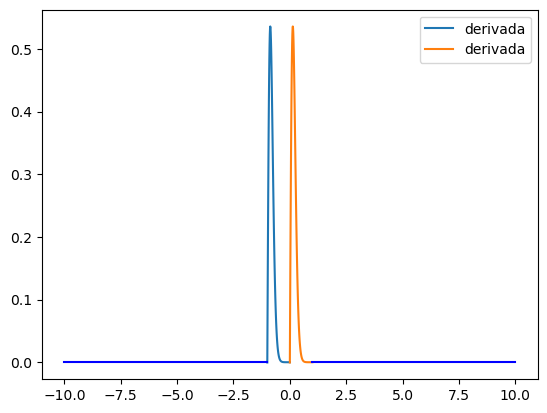

In [73]:
from scipy.special import airy

#De la siguiente gŕafica 

x = np.linspace(-20, 10, 200)
y = np.zeros_like(x)
Ai = airy(x)[0]     #Función Ai(x)  
#plt.plot(x,y)
#plt.plot(x, Ai)
#plt.grid()
#plt.show()

#Se observa que la raíz más cercana al cero está en el intervalo (-3,0), voy a aproximar la raíz 

x = np.linspace(-3, 0, 500)
y = np.zeros_like(x)
Ai = abs(airy(x)[0])     #Función Ai(x), lo pongo en valor absoluto para poder calcular el mínimo con la libreria numpy
#plt.plot(x,y)
#plt.plot(x, Ai)
#plt.grid()
#plt.show()

a0 = x[np.argmin(Ai)] 

#Ahora sí, la función

x = np.linspace(0, 1, 100)
f = airy((10*x)+a0)[0]

def g(x,f,n):
    for i in range(-1,1,1):
        x1 = np.linspace(i,i+1,100)
        plt.plot(x1,f,color="blue")
    x0 = np.linspace(-n,-1,100)
    y0 = np.linspace(1,n,100)
    y = np.zeros_like(x0)
    plt.plot(x0,y,color="blue")
    plt.plot(y0,y,color="blue")

g(x,f,10)



3. Dibuje la primera y segunda derivada de la función $g(x)$ del problema anterior en el intervalo $x \in [-10,10]$. 

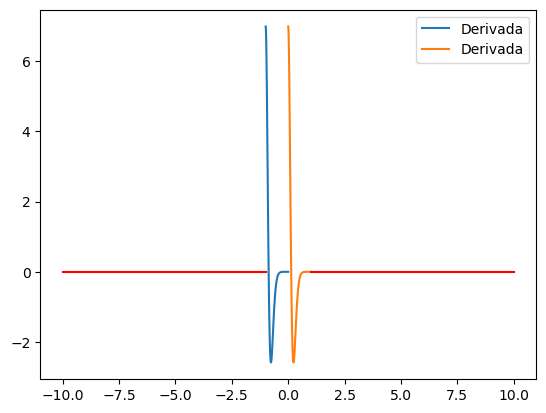

In [74]:
def deriv_sim(f,x):
    df = np.zeros_like(f)
    for i in range(1,len(x)-1):
        df[i] = (f[i+1]-f[i-1])/(x[i+1]-x[i-1])
    df[0] = (f[1]-f[0])/(x[1]-x[0])
    df[-1] = -(f[-2]-f[-1])/(x[-1]-x[-2])
    return df

x = np.linspace(0, 1, 100)
f = airy((10*x)+a0)[0]
derv = deriv_sim(f,x)

for i in range(-1,1,1):
    x1 = np.linspace(i,i+1,100)
    mi_plot(x1,derv,gap=1,label="Derivada")   #usé la función del primer ejercicio para evitar los saltos
x0 = np.linspace(-10,-1,100)
y0 = np.linspace(1,10,100)
y = np.zeros_like(x0)
plt.plot(x0,y,color="red")
plt.plot(y0,y,color="red")




4. Considere la siguiente suma:
$$
a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ ...}}}}
$$
Para hacer esta suma, vea lo que sucede con la suma a cada paso. Por ejemplo:

* Paso 1: $a = 1 + \frac{1}{2}$

* Paso 2: $a = 1 + \frac{1}{2+ \frac{1}{2}}$

* Paso 3: $a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2}}}$

Haga una función que calcule la suma para $N$ pasos. Haga la gráfica de la convergencia de la suma anterior, es decir, la gráfica que tenga en el eje $x$ los pasos y en el eje $y$ el valor de la suma. ¿Cómo se compara la suma con el valor de $\sqrt{2}$? y ¿Cuántos términos se tienen que tomar para que las variaciones en la suma sean menores a $1 \times 10^{-6}$?

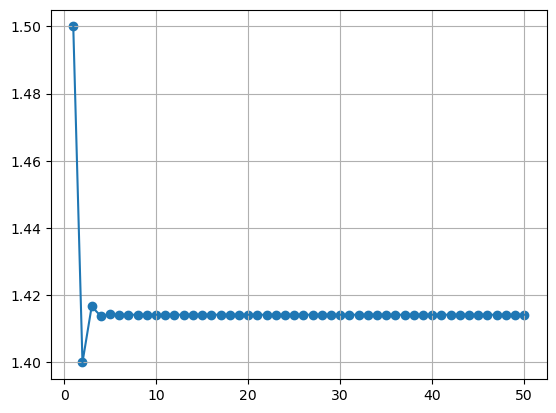

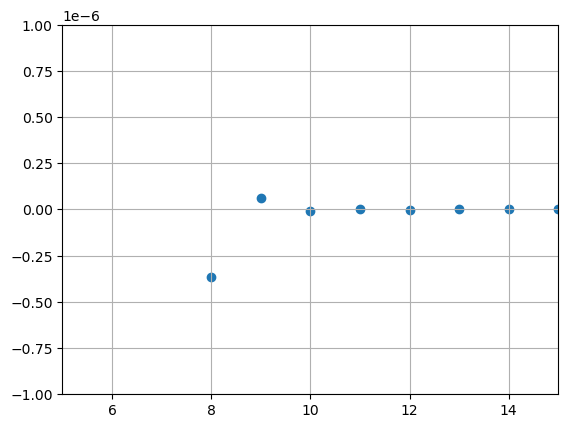

In [25]:
def S(n):
    if n==1:
        y=1 + (1/2)     #puse a parte los primeros dos elementos de la sucesión
    elif n==2:
        y=1 + 1/(2+(1/2))
    else:
        m=0
        y=2+(1/2)
        while m <= n-2:    #le quito dos para que jale a partir de n=3
            y=1/y
            y=2+y
            m = m+1
        y= y-1           # como en el bucle le suma de dos en dos, debo quitarle un uno
    return y

su = []
for i in range(1,51):
    z = S(i)
    su.append(z)

#grafica de los puntos ()
x = np.linspace(1,50,50)
plt.figure(1)
plt.plot(x,su)
plt.scatter(x,su)
plt.grid()

#diferencia 
diferencia = []
for i in range(1,51):
    z = S(i)-np.sqrt(2)
    diferencia.append(z)
plt.figure(2)
plt.xlim(5,15)
plt.ylim(-10**-6,10**-6)
plt.scatter(x,diferencia)
plt.grid()

#se observa en la gráfica que es a partir del octavo término que la diferencia entre la suma y la raíz de dos es menor a 1x10^-6